# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

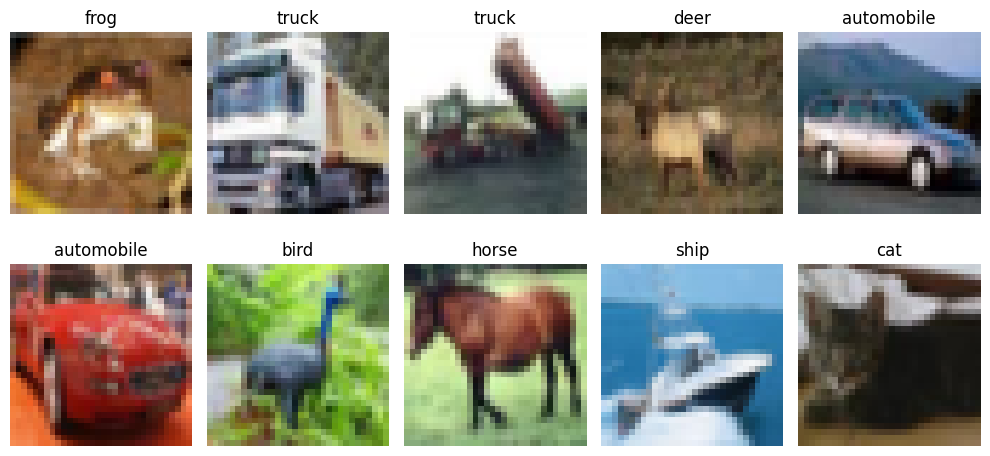

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.2738 - loss: 1.9878 - val_accuracy: 0.3476 - val_loss: 1.8315
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3206 - loss: 1.8633 - val_accuracy: 0.3688 - val_loss: 1.7840
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.3413 - loss: 1.8092 - val_accuracy: 0.3806 - val_loss: 1.7490
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3544 - loss: 1.7703 - val_accuracy: 0.4020 - val_loss: 1.7084
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.3625 - loss: 1.7530 - val_accuracy: 0.4026 - val_loss: 1.6885
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3741 - loss: 1.7217 - val_accuracy: 0.4170 - val_loss: 1.6583
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3831 - loss: 1.7070 - val_accuracy: 0.4176 - val_loss: 1.6452
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.3883 - loss: 1.6940 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4241 - loss: 1.6181
ANN Test Accuracy: 0.42410001158714294


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 136ms/step - accuracy: 0.4669 - loss: 1.4941 - val_accuracy: 0.5836 - val_loss: 1.1776
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6048 - loss: 1.1294 - val_accuracy: 0.5696 - val_loss: 1.2184
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.6694 - loss: 0.9533 - val_accuracy: 0.6424 - val_loss: 1.0690
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7114 - loss: 0.8331 - val_accuracy: 0.6934 - val_loss: 0.9116
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7439 - loss: 0.7360 - val_accuracy: 0.6770 - val_loss: 0.9329
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 131ms/step - accuracy: 0.7691 - loss: 0.6588 - val_accuracy: 0.7092 - val_loss: 0.8665
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.7943 - loss: 0.5841 - val_accuracy: 0.6888 - val_loss: 0.9442
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 129ms/step - accuracy: 0.8143 - loss:

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7259 - loss: 0.9061
CNN Test Accuracy: 0.7258999943733215


# Experiment 1: Deep ANN

---



In [9]:
from tensorflow.keras import layers, models

deep_ann = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

deep_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deep_ann_loss, deep_ann_acc = deep_ann.evaluate(
    x_test_flat,
    y_test
)

print("Deep ANN Accuracy:", deep_ann_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 69ms/step - accuracy: 0.2508 - loss: 2.0363 - val_accuracy: 0.3292 - val_loss: 1.8583
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 0.3049 - loss: 1.8903 - val_accuracy: 0.3580 - val_loss: 1.8282
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.3239 - loss: 1.8452 - val_accuracy: 0.3676 - val_loss: 1.8158
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.3363 - loss: 1.8157 - val_accuracy: 0.3724 - val_loss: 1.7647
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.3495 - loss: 1.7874 - val_accuracy: 0.3924 - val_loss: 1.7229
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.3618 - loss: 1.7586 - val_accuracy: 0.3870 - val_loss: 1.7067
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.3675 - loss: 1.7480 - val_accuracy: 0.3960 - val_loss: 1.7083
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.3688 - loss: 1.7365 - 

The ANN was made deeper by adding more neurons and an extra hidden layer to see if it could learn image features better.

Accuracy: 41.81%

The accuracy was slightly lower than the original ANN (42.41%), showing that increasing ANN depth alone does not necessarily improve image classification performance.

# Experiment 2: CNN With More Filters

In [10]:
cnn_large = models.Sequential([

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        256,
        (3,3),
        activation='relu'
    ),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_large.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_large_history = cnn_large.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_large_loss, cnn_large_acc = cnn_large.evaluate(
    x_test_norm,
    y_test
)

print("CNN Large Accuracy:", cnn_large_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 245s 344ms/step - accuracy: 0.4954 - loss: 1.4254 - val_accuracy: 0.5350 - val_loss: 1.2955
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 245s 349ms/step - accuracy: 0.6440 - loss: 1.0292 - val_accuracy: 0.5566 - val_loss: 1.3090
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 246s 350ms/step - accuracy: 0.7082 - loss: 0.8448 - val_accuracy: 0.6060 - val_loss: 1.1233
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 346ms/step - accuracy: 0.7538 - loss: 0.7081 - val_accuracy: 0.7236 - val_loss: 0.8299
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 247s 350ms/step - accuracy: 0.7876 - loss: 0.6031 - val_accuracy: 0.7272 - val_loss: 0.8321
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 348ms/step - accuracy: 0.8238 - loss: 0.4989 - val_accuracy: 0.7048 - val_loss: 0.9361
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 256s 340ms/step - accuracy: 0.8517 - loss: 0.4231 - val_accuracy: 0.6526 - val_loss: 1.1498
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 239s 340ms/step - accuracy: 0.8739 -

The number of filters was increased to allow the model to learn more detailed image features.

Accuracy: 69.11%

Despite having more filters, the model performed worse than the original CNN (72.59%), suggesting that a larger model may not always generalize better.

# Experiment 3: CNN With More Epochs (20)

In [11]:
cnn_20epochs = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

cnn_20epochs.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn20_history = cnn_20epochs.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn20_loss, cnn20_acc = cnn_20epochs.evaluate(
    x_test_norm,
    y_test
)

print("CNN 20 Epoch Accuracy:", cnn20_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 129ms/step - accuracy: 0.4654 - loss: 1.5021 - val_accuracy: 0.5742 - val_loss: 1.2075
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.6092 - loss: 1.1187 - val_accuracy: 0.5142 - val_loss: 1.5006
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.6665 - loss: 0.9608 - val_accuracy: 0.6562 - val_loss: 0.9893
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7080 - loss: 0.8424 - val_accuracy: 0.6696 - val_loss: 0.9636
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7400 - loss: 0.7447 - val_accuracy: 0.6388 - val_loss: 1.1173
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 129ms/step - accuracy: 0.7654 - loss: 0.6666 - val_accuracy: 0.6778 - val_loss: 0.9773
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 126ms/step - accuracy: 0.7882 - loss: 0.6036 - val_accuracy: 0.6986 - val_loss: 0.9572
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 128ms/step - accuracy: 0.8088 - loss

The model was trained for more epochs to check whether longer training improves performance.

Accuracy: 70.87%

Training for additional epochs did not improve the final accuracy and may have led to slight overfitting.

# Experiment 4: CNN With Early Stopping

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_early = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

cnn_early.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_early_history = cnn_early.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_early_loss, cnn_early_acc = cnn_early.evaluate(
    x_test_norm,
    y_test
)

print("CNN Early Stopping Accuracy:", cnn_early_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 129ms/step - accuracy: 0.4622 - loss: 1.4973 - val_accuracy: 0.5258 - val_loss: 1.3035
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 131ms/step - accuracy: 0.6099 - loss: 1.1216 - val_accuracy: 0.5510 - val_loss: 1.2688
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 130ms/step - accuracy: 0.6722 - loss: 0.9420 - val_accuracy: 0.6442 - val_loss: 1.0045
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.7141 - loss: 0.8244 - val_accuracy: 0.7136 - val_loss: 0.8293
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 128ms/step - accuracy: 0.7459 - loss: 0.7302 - val_accuracy: 0.6858 - val_loss: 0.9170
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.7724 - loss: 0.6559 - val_accuracy: 0.7074 - val_loss: 0.9351
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.7960 - loss: 0.5809 - val_accuracy: 0.7040 - val_loss: 0.9157
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7039 - loss: 0.8474
CNN 

Early Stopping was used to automatically stop training when validation performance stopped improving.

Accuracy: 70.39%

The model achieved good performance while avoiding unnecessary training.

# Experiment 5: CNN With Data Augmentation

In [20]:
aug_cnn = models.Sequential([
    data_augmentation,

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

# IMPORTANT
aug_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_loss, aug_acc = aug_cnn.evaluate(
    x_test_norm,
    y_test
)

print("CNN + Augmentation Accuracy:", aug_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 104s 143ms/step - accuracy: 0.4005 - loss: 1.6630 - val_accuracy: 0.4964 - val_loss: 1.4094
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 145ms/step - accuracy: 0.5025 - loss: 1.4081 - val_accuracy: 0.4024 - val_loss: 1.8113
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.5447 - loss: 1.2932 - val_accuracy: 0.6032 - val_loss: 1.1374
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 146ms/step - accuracy: 0.5709 - loss: 1.2205 - val_accuracy: 0.5690 - val_loss: 1.2245
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 145ms/step - accuracy: 0.5911 - loss: 1.1619 - val_accuracy: 0.6100 - val_loss: 1.1172
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 152ms/step - accuracy: 0.6114 - loss: 1.1173 - val_accuracy: 0.5860 - val_loss: 1.2361
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 147ms/step - accuracy: 0.6228 - loss: 1.0794 - val_accuracy: 0.5786 - val_loss: 1.2540
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 144ms/step - accuracy: 0.6405 -

Data augmentation was applied to create more diverse training samples through image transformations.

Accuracy: 63.72%

The model achieved lower accuracy than the original CNN, but the experiment demonstrates the effect of augmentation on the training process.

# Final Comparison Table

In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "Deep ANN",
        "CNN",
        "CNN More Filters",
        "CNN 20 Epochs",
        "CNN EarlyStopping",
        "CNN + Augmentation"
    ],

    "Test Accuracy": [
        ann_test_acc,
        deep_ann_acc,
        cnn_test_acc,
        cnn_large_acc,
        cnn20_acc,
        cnn_early_acc,
        aug_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4241
1,Deep ANN,0.4181
2,CNN,0.7259
3,CNN More Filters,0.6911
4,CNN 20 Epochs,0.7087
5,CNN EarlyStopping,0.7039
6,CNN + Augmentation,0.6922


# Final Comparison Bar Graph

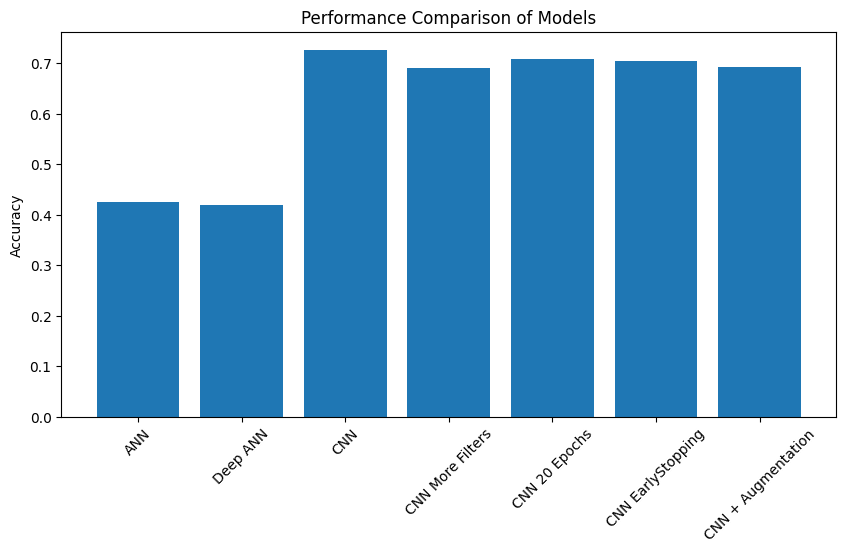

In [22]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Performance Comparison of Models")

plt.show()

**Line Chart**

The line chart compares the validation accuracy of CNN trained for 20 epochs and CNN trained with data augmentation. The CNN 20 Epochs model consistently achieved higher validation accuracy throughout training. The augmented CNN also showed steady improvement but achieved lower validation accuracy overall. This suggests that, in our experiments, increasing training duration was more beneficial than the chosen augmentation strategy.

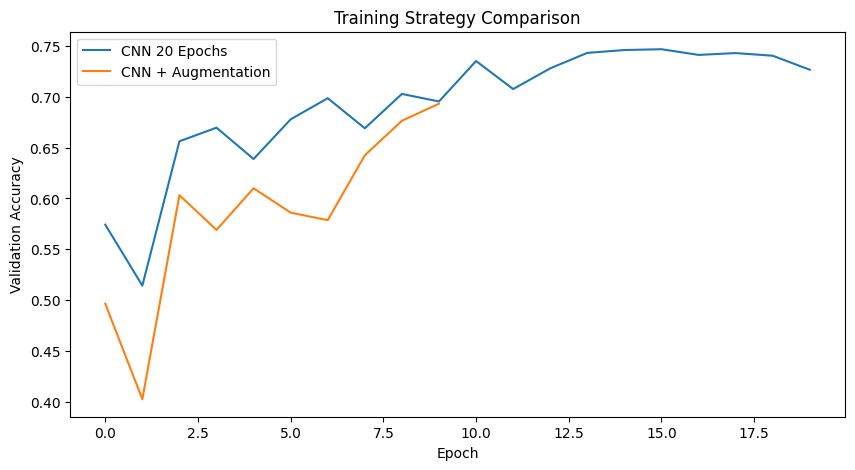

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    cnn20_history.history['val_accuracy'],
    label='CNN 20 Epochs'
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='CNN + Augmentation'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title("Training Strategy Comparison")

plt.legend()

plt.show()

## Overall Analysis

The ANN models achieved the lowest accuracies because they treat images as flattened vectors and cannot preserve spatial relationships between pixels.

CNN-based models significantly outperformed ANN models because convolutional layers can automatically learn hierarchical image features such as edges, textures, and object shapes.

Among all experiments, the original CNN achieved the highest test accuracy of 72.59%. Increasing the number of filters and training for more epochs did not improve performance, indicating that larger models are more prone to overfitting. Early Stopping successfully reduced unnecessary training, while Data Augmentation demonstrated a strategy for improving dataset diversity.

Overall, the results confirm that CNN architectures are more suitable than ANN architectures for image classification tasks on the CIFAR-10 dataset.

## 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**